In [2]:
# # Test Case
# # df2
# # 2014-10-01
# # windspeed:(daily average)
# ws = 1.75
# # temperature: (period of day)
# t_max = 31.25
# t_min = 21.68

# #solar radiation (daily average)
# Srad = 81.28

# # elevation above sea level, m  (austin, change later)
# z=149.0472

# #relative humidity 
# RH_min = 48.37
# RH_max = 95.1

# #Number of days in the year
# J=273

# #Coordination
# coor1 = (-98.6105, 30.3989)# (lon, lat)


In [3]:
import datetime
from datetime import date
from datetime import datetime
import math as m
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline

from pandas.core.frame import DataFrame



In [7]:
# Read datasets and set the index to be the date
SM1 = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_1_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
SM2 = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_2_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
SM3 = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_3_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
SM4 = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_4_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
SM5 = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_5_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
SM6 = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_6_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")

In [28]:
# Read datasets and set the index to be the date
df1 = pd.read_csv('../datasets/TX-Data/met_station/met_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('../datasets/TX-Data/met_station/met_2.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('../datasets/TX-Data/met_station/met_3.dat', sep=",", parse_dates=["Date"], index_col="Date")
df4 = pd.read_csv('../datasets/TX-Data/met_station/met_4.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('../datasets/TX-Data/met_station/met_5.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('../datasets/TX-Data/met_station/met_6.dat', sep=",", parse_dates=["Date"], index_col="Date")

In [29]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float) 

In [30]:
def remove_spaces_and_change_types(df):
  df.columns = df.columns.str.replace(' ','')
  df['SWC_5'] = df['SWC_5'].astype(float)
  df['SWC_10'] = df['SWC_10'].astype(float)
  df['SWC_20'] = df['SWC_20'].astype(float)
  df['SWC_50'] = df['SWC_50'].astype(float)


In [31]:
remove_spaces(df2)
remove_spaces_and_change_types(SM2)

In [32]:
# combine soil data with station data
df2.drop(['Ppt'],axis=1)
DF2 =pd.merge(df2,SM2,left_index=True,right_index=True)

In [45]:
DF2.describe()

,Ppt_x,Tair,RH,Windspeed,Winddirection,Srad,Ppt_y,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
count,56366.000000,56366.000000,56366.000000,56366.00000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,58441.000000
mean,0.077035,18.785294,64.956038,1.42183,139.013725,197.123425,0.076988,0.183168,0.171224,0.221455,0.374115,21.937539,21.860811,21.854096,21.850310,379.806608
std,0.834520,9.229105,29.001494,1.26508,98.129145,290.320827,0.834503,0.062314,0.055984,0.058178,0.088946,8.171939,7.870336,7.493698,6.541887,2065.702185
min,0.000000,-17.300000,0.190000,0.00000,0.000000,0.000000,0.000000,0.079000,0.079000,0.123000,0.223000,2.360000,3.180000,4.330000,7.960000,0.000000
25%,0.000000,12.620000,46.180000,0.15000,39.500000,0.000000,0.000000,0.121000,0.115000,0.163000,0.291000,15.280000,15.280000,15.320000,15.850000,0.000000
50%,0.000000,20.150000,72.540000,1.29300,157.200000,7.215000,0.000000,0.188000,0.171000,0.225000,0.381000,21.810000,21.740000,21.645000,21.390000,0.000000
75%,0.000000,25.140000,89.200000,2.28200,203.900000,344.475000,0.000000,0.239000,0.220000,0.270000,0.462000,28.330000,28.260000,28.290000,27.710000,0.000000
max,53.340000,42.140000,100.000000,7.70500,360.000000,1086.000000,53.340000,0.320000,0.301000,0.364000,0.508000,48.530000,43.460000,38.910000,34.790000,13107.000000


In [34]:
import datetime
def find_configue(time):
    time=str(time)
    # time='2014-10-05'

    # number of day in a year
    datem = datetime.datetime.strptime(time,"%Y-%m-%d")
    d1=date(datem.year,datem.month,datem.day)
    d0 = date(datem.year,1,1)
    delta = d1 - d0
    J=delta.days
#     print('day of year: ',J)


    D = DF2.loc[time]
#     print(D)

    #temperature
    Tair=D.iloc[:,1]
    temperature=[]
    for i in range(len(D)):
        temperature.append(Tair[i])
    t_max = None
    for num in temperature:
        if (t_max is None or num > t_max):
            t_max = num
#     print('t_max ',t_max)
    t_min =None
    for t in temperature:
        if(t_min is None or t < t_min):
            t_min = t
#     print('t_min ',t_min)

    #RH
    RH = D.iloc[:,2]
    relative_humidity=[]
    for i in range(len(D)):
        relative_humidity.append(RH[i])
    RH_max = None
    for num in relative_humidity:
        if (RH_max is None or num > RH_max):
            RH_max = num
#     print('RH_max ',RH_max)
    RH_min =None
    for t in relative_humidity:
        if(RH_min is None or t < RH_min):
            RH_min = t
#     print('RH_min ',RH_min)

    #Srad
    Srad = D.iloc[:,5]
#     Srad.astype(int)
#     print('avg_Srad ',sum(Srad)/len(Srad))

    #ws
    ws = D.iloc[:,3]
#     print(type(ws))
    
    #SWC_5
    SWC_5 = D.iloc[:,7]

    #Coordination
    coor1 = (-98.6105, 30.3989)# (lon, lat)

    # elevation above sea level, m  (austin, change later)
    z=149.0472
    return J, t_max, t_min, RH_max, RH_min, sum(Srad)/len(Srad), sum(ws)/len(ws), z, coor1,sum(SWC_5)/len(SWC_5)

In [35]:
def Find_ET0(ws,t_max,t_min,Srad,z,RH_min,RH_max,J,coor1):
    J, t_max, t_min, RH_max, RH_min, Srad, ws, z, coor1,SWC_5=find_configue(time)
    t_mean = (t_max+t_min)*(1/2)
    Srad = Srad *0.0864
    u_0 = ws
    u_2 = u_0 * 4.87/(np.log(67.8 * u_0 - 5.42))
    delta = 4098 * (0.6108*m.exp(17.27*t_mean/(t_mean+237.3)))*(1/(t_mean+237.2))**2
    P = 101.3*(((293-0.0065*z)/293)**5.26)
    p_constant = 0.000665*P
    DT = delta/(delta + p_constant*(1+0.34*u_2))
    PT = p_constant/(delta + p_constant*(1+0.34*u_2))
    TT = (900/(t_mean+273))*u_2
    eT_max= 0.6108*m.exp(17.27*t_max/(t_max+237.3))
    eT_min= 0.6108*m.exp(17.27*t_min/(t_min+237.3))
    es = (eT_max+eT_min)/2
    ea = ((eT_min)*(RH_max/100)+(eT_max)*(RH_min/100))/2
    dr = 1+0.033*m.cos(2*m.pi/365*J)
    Sd = 0.409*m.sin(2*m.pi/365*J-1.39)
    Longitude= coor1[1]
    Ws = np.arccos(-1*m.tan(Sd)*m.tan(Longitude))
    Ra = 24*60/m.pi*0.082*dr*((Ws*m.sin(Longitude)*m.sin(Sd))+(m.cos(Longitude)*m.cos(Sd)*m.sin(Ws)))
    Rso = (0.75 + 0.00002*z)*Ra
    a = 0.23 # albedo or canopy reflection coefficient
    Rns = (1-a)*Srad
    Rnl= 4.903 *(10**(-9))*(((t_max+273.14)**4+(t_min+273.16)**4)/2)*(0.34-0.14*(ea)**(1/2))*(1.35*Srad/Rso-0.35)
#     Rn= Rns -Rnl
    Rn= Rnl -Rns
    Rng = Rn *0.408
    ETrad = DT*Rng
    ETwind = PT * TT *(es-ea)
    ET0=ETrad+ETwind
    return ET0,SWC_5



In [36]:
time2 =DF2.index.to_list()
result=[]
for i in time2:
    i=i.date()
    result.append(i)
    
# function to find unique days
def unique(list1):
    x = np.array(list1)
    uni =np.unique(x)
    return uni
t=list(unique(result))

ET0_list=[]
SWC_5_list=[]
for i in t:
    time = str(i)
    J, t_max, t_min, RH_max, RH_min, Srad, ws, z, coor1,SWC_5=find_configue(time)
    ET0,SWC_5=Find_ET0(ws,t_max,t_min,Srad,z,RH_min,RH_max,J,coor1)
    ET0_list.append(ET0)
    SWC_5_list.append(SWC_5)


c = {'date':t,'ET0':ET0_list,'SWC_5':SWC_5_list}
df = DataFrame(c)
df


,date,ET0,SWC_5
0,2015-01-01,-0.304577,0.188042
1,2015-01-02,0.040716,0.204375
2,2015-01-03,0.061769,0.254333
3,2015-01-04,-0.923432,0.238708
4,2015-01-05,-0.695357,0.234958
...,...,...,...
2431,2021-08-28,NaN,NaN
2432,2021-08-29,NaN,NaN
2433,2021-08-30,NaN,NaN
2434,2021-08-31,NaN,NaN


Text(0, 0.5, 'ETO(mm/day-1)')

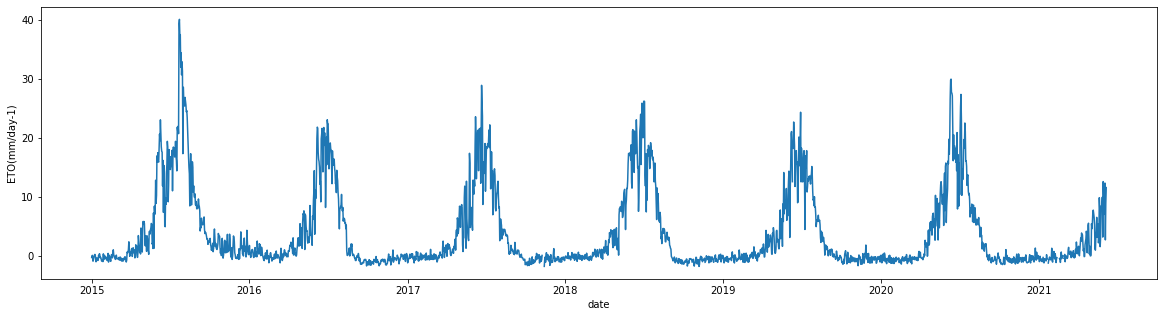

In [37]:
plt.figure(figsize=(20,5))
plt.plot(df['date'], df['ET0'])
plt.xlabel('date')
plt.ylabel('ETO(mm/day-1)')

Text(0, 0.5, 'SWC_5')

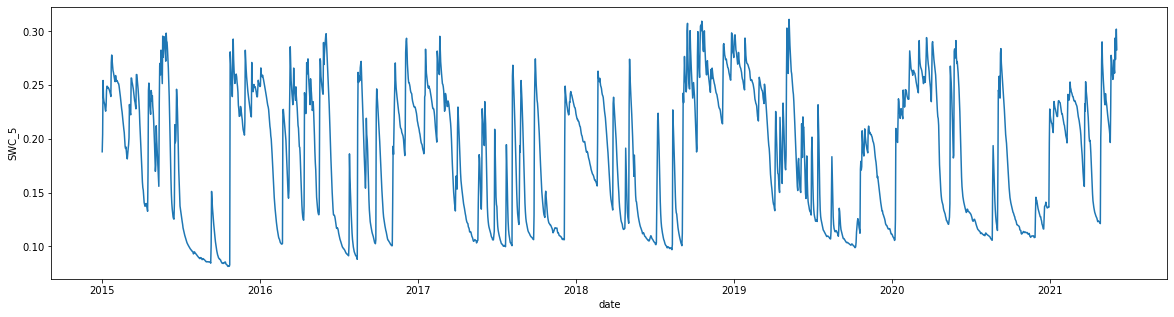

In [38]:
plt.figure(figsize=(20,5))
plt.plot(df['date'], df['SWC_5'])
plt.xlabel('date')
plt.ylabel('SWC_5')

<function matplotlib.pyplot.show(close=None, block=None)>

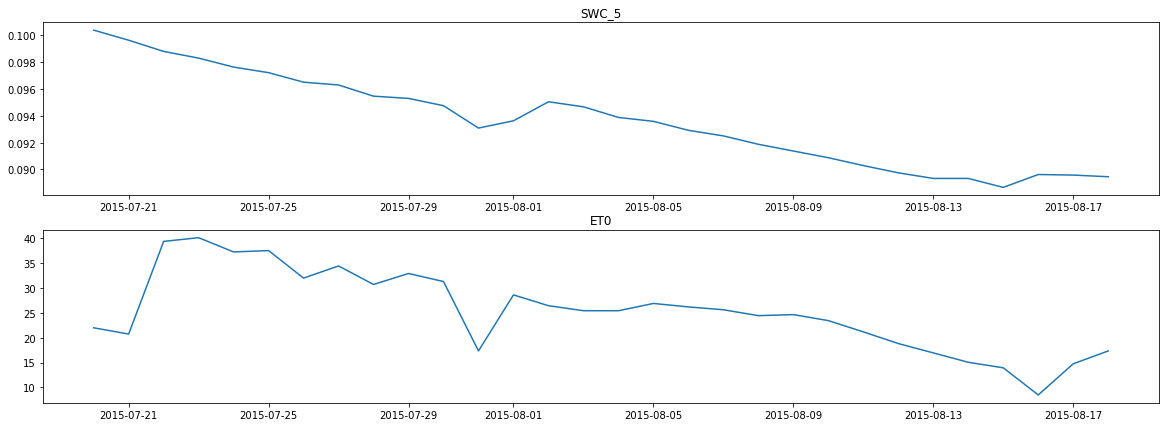

In [47]:
plt.figure(figsize=(20,7))
plt.subplot(211)
plt.plot(df['date'][200:230], df['SWC_5'][200:230])
plt.title("SWC_5")

plt.subplot(212)
plt.plot(df['date'][200:230], df['ET0'][200:230])
plt.title("ET0")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

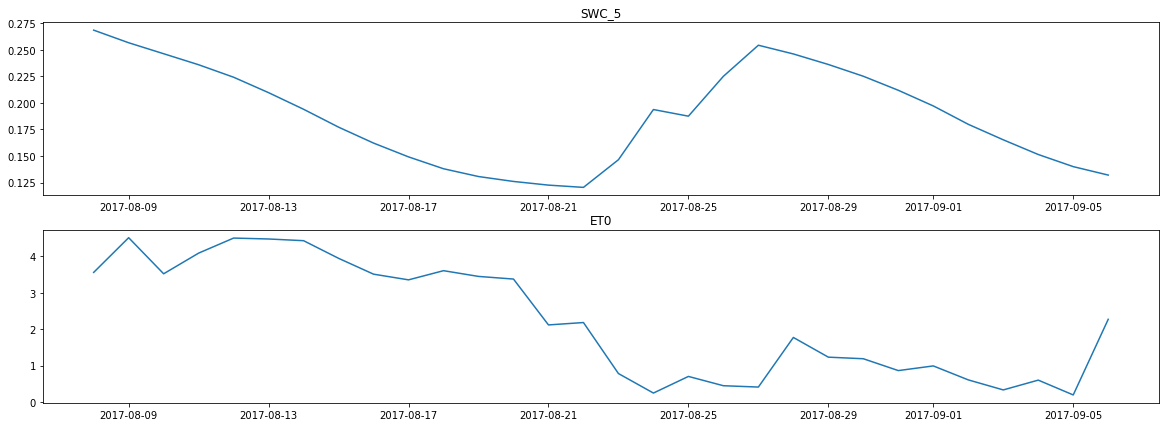

In [57]:
plt.figure(figsize=(20,7))
plt.subplot(211)
plt.plot(df['date'][950:980], df['SWC_5'][950:980])
plt.title("SWC_5")

plt.subplot(212)
plt.plot(df['date'][950:980], df['ET0'][950:980])
plt.title("ET0")
plt.show

##### Steps

In [136]:
time = '2015-05-10'
J, t_max, t_min, RH_max, RH_min, Srad, ws, z, coor1=find_configue(time)

In [137]:
#Step1
t_mean = (t_max+t_min)*(1/2)

In [138]:
#Step2 (MJ m^-2) unit transformation
Srad = Srad *0.0864  

In [139]:
#Step3 Wind Speed (m/s-1)
u_0 = ws
u_2 = u_0 * 4.87/(np.log(67.8 * u_0 - 5.42))

In [140]:
#Step4 slope of saturation
delta = 4098 * (0.6108*m.exp(17.27*t_mean/(t_mean+237.3)))*(1/(t_mean+237.2))**2

In [141]:
#Step5 Atomspheric Pressure (kpa)
P= 101.3*(((293-0.0065*z)/293)**5.26)

In [196]:
#Step6 Psychrometric constant (kPa C^-1)
p_constant = 0.000665*P
print(p_constant)

0.06620110299254418


In [143]:
#Step7 Delta Term
DT = delta/(delta + p_constant*(1+0.34*u_2))

In [144]:
#Step8 Psi Term
PT = p_constant/(delta + p_constant*(1+0.34*u_2))

In [145]:
#Step9 Temperature Term 
TT = (900/(t_mean+273))*u_2

In [146]:
#Step10 mean saturation vapor pressure (es) derieved from air tempuature (kPa)
eT_max= 0.6108*m.exp(17.27*t_max/(t_max+237.3))
eT_min= 0.6108*m.exp(17.27*t_min/(t_min+237.3))
# es mean (kpa)
es = (eT_max+eT_min)/2

In [147]:
#Step11 Actual vapor pressure(ea) derieved from relative humidty (absence of huminity data)
ea = ((eT_min)*(RH_max/100)+(eT_max)*(RH_min/100))/2

In [148]:
print(ea,es)

2.348556454406002 3.1057850723090477


In [149]:
#Step12 The inverse relative distance Earth-Sun(dr)
# Solar declination(Sd)
dr = 1+0.033*m.cos(2*m.pi/365*J)
Sd = 0.409*m.sin(2*m.pi/365*J-1.39)


In [150]:
#Step13 Conversion of Latitude in degree to radians(pass)
Longitude= coor1[1]

#Step14 Sunset hour angel 
Ws = np.arccos(-1*m.tan(Sd)*m.tan(Longitude))

In [151]:
# Step15 Ectraterrestrial radiation
Ra = 24*60/m.pi*0.082*dr*((Ws*m.sin(Longitude)*m.sin(Sd))+(m.cos(Longitude)*m.cos(Sd)*m.sin(Ws)))


In [152]:
#Step16 Clear sky solar radiation(Rso)
Rso = (0.75 + 0.00002*z)*Ra
print(Rso)

4.713139525198368


In [153]:
# Step17 Net solar or net shortwave radiation(Rns)
a = 0.23 # albedo or canopy reflection coefficient
Rns = (1-a)*Srad

In [154]:
print(Rns)

12.97867032


In [155]:
# Step18 Net outcoming long wave solar radiation(Rnl)
Rnl= 4.903 *(10**(-9))*(((t_max+273.14)**4+(t_min+273.16)**4)/2)*(0.34-0.14*(ea)**(1/2))*(1.35*Srad/Rso-0.35)
print(Rnl)

21.627250736901928


In [182]:
#Step19 Net radiation(Rng) (mm)
Rn= Rns -Rnl
# Rn=Rnl-Rns
Rng = Rn *0.408


In [183]:
# Final Step
# Radiation Term(ETrad) (mm*d^-1)
ETrad = DT*Rng

#Wind Term(ETwind)((mm*d^-1))
ETwind = PT * TT *(es-ea)

In [184]:
ET0=ETrad+ETwind
print(ETrad)
print(ETwind)
print(ET0)

-2.088234975090326
1.3151586544373826
-0.7730763206529436
